Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 118ms/step - accuracy: 0.3987 - loss: 1.5462 - val_accuracy: 0.3828 - val_loss: 1.5207
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - accuracy: 0.6297 - loss: 0.9108 - val_accuracy: 0.3594 - val_loss: 1.4370
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - accuracy: 0.6866 - loss: 0.7581 - val_accuracy: 0.3734 - val_loss: 1.4219
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - accuracy: 0.7178 - loss: 0.6722 - val_accuracy: 0.4156 - val_loss: 1.3221
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - accuracy: 0.7153 - loss: 0.6313 - val_accuracy: 0.4781 - val_loss: 1.0916
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - accuracy: 0.7639 - loss: 0.5475 - val_accuracy: 0.5969 - val_loss: 0.8630
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 126ms/step - accuracy: 0.7108 - loss: 0.5660 - val_accuracy: 0.6625 - val_loss: 0.7427
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step - accuracy: 0.7417 - loss: 0.5087 - val_accuracy:

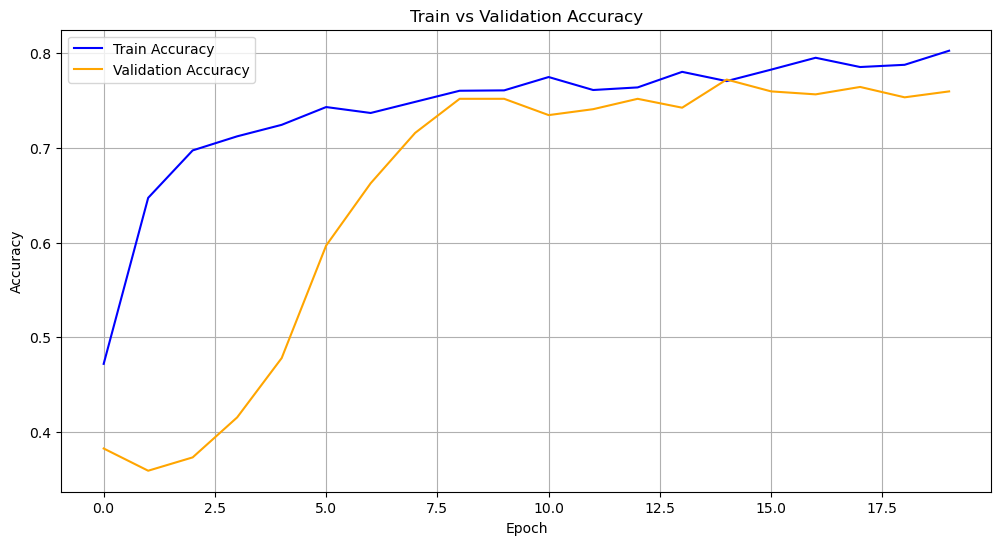

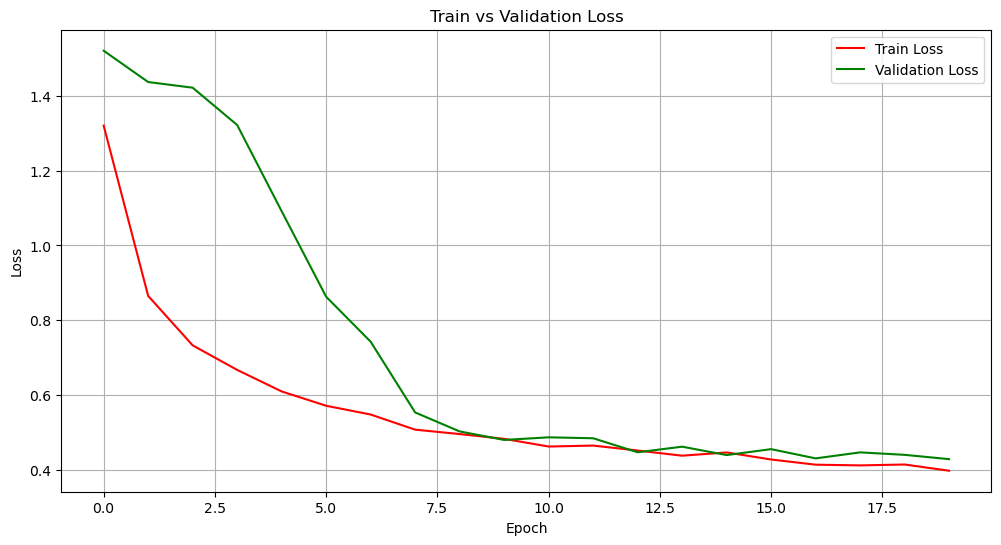


Classification Report on Validation Data:
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
              precision    recall  f1-score   support

           0       0.67      0.79      0.72       256
           1       0.44      0.32      0.37       138
           2       1.00      0.96      0.98       118
           3       1.00      1.00      1.00       128

    accuracy                           0.76       640
   macro avg       0.78      0.77      0.77       640
weighted avg       0.75      0.76      0.75       640


Predictions on Test Data:
1.jpg: alligator = 58.91%
10.jpg: alligator = 67.09%
100.jpg: alligator = 53.76%
1000.jpg: komodo = 94.13%
1001.jpg: komodo = 99.93%
1002.jpg: komodo = 99.80%
1003.jpg: komodo = 99.64%
1004.jpg: komodo = 99.97%
1005.jpg: komodo = 98.43%
1006.jpg: komodo = 98.23%
1007.jpg: komodo = 97.15%
1008.jpg: komodo = 98.86%
1009.jpg: komodo = 99.97%
101.jpg: crocodile = 54.81%
1010.jpg: komodo = 99.91%
1011.jpg: komodo = 56.34%
1012.jpg: komodo = 99.98%
1013.jpg

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from data_prep import ImageDataLoader
from model import get_model
from sklearn.metrics import classification_report

EPOCHS = 20  # Number of epochs for training

def train_and_evaluate():
    """
    Function to load data, train the model, and evaluate it.
    This will also generate accuracy and loss plots, and save them.
    """
    # Set up data loader for training and testing
    data_loader = ImageDataLoader(train_dir=r"C:\Users\CERTAN\train", test_dir=r"C:\Users\CERTAN\test1")
    # Load training and validation data
    X_train, X_val, y_train, y_val = data_loader.load_data()

    # Load test data
    X_test, filenames = data_loader.load_test_data()

    # Normalize data
    X_train, X_val = X_train / 255.0, X_val / 255.0
    X_test = X_test / 255.0

    # Load the model
    model = get_model()

    # Train the model
    history = model.fit(
        X_train, y_train, epochs=EPOCHS, validation_data=(X_val, y_val), verbose=1
    )

    # Evaluate the model on validation data
    val_loss, val_accuracy = model.evaluate(X_val, y_val)
    print(f"Validation Accuracy: {val_accuracy:.2%}")

    # Predict test data
    predictions = model.predict(X_test)
    predicted_classes = np.argmax(predictions, axis=1)

    # Generate accuracy and loss plots
    plot_accuracy(history)
    plot_loss(history)

    # Print classification report for validation data
    print("\nClassification Report on Validation Data:")
    print(classification_report(y_val, np.argmax(model.predict(X_val), axis=1)))

    # Print predictions with confidence scores
    print("\nPredictions on Test Data:")
    display_predictions(predictions, filenames, data_loader.labels)

    return history, predictions, filenames

def plot_accuracy(history):
    """
    Plot and save the training and validation accuracy.
    """
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Train vs Validation Accuracy')
    plt.grid(True)
    plt.savefig('accuracy.jpg', dpi=300)
    plt.show()

def plot_loss(history):
    """
    Plot and save the training and validation loss.
    """
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'], label='Train Loss', color='red')
    plt.plot(history.history['val_loss'], label='Validation Loss', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Train vs Validation Loss')
    plt.grid(True)
    plt.savefig('loss.jpg', dpi=300)
    plt.show()

def display_predictions(predictions, filenames, labels):
    """
    Display predictions with confidence scores.
    """
    for idx, pred in enumerate(predictions):
        predicted_label = labels[np.argmax(pred)]
        confidence = np.max(pred) * 100
        print(f"{filenames[idx]}: {predicted_label} = {confidence:.2f}%")

# Run the training and evaluation
history, predictions, filenames = train_and_evaluate()
